In [63]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [64]:
words = open('names.txt', 'r').read().splitlines()
print(len(words))
words[:8]

32033


['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [65]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}

In [66]:
block_size = 3
X, Y = [], []
for w in words[:5]:
    print(w)
    context = [0] * block_size
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        print(''.join(itos[i] for i in context), '--->', itos[ix])
        #print(context)
        context = context[1:] + [ix]
X = torch.tensor(X)
Y = torch.tensor(Y)
        

emma
... ---> e
..e ---> m
.em ---> m
emm ---> a
mma ---> .
olivia
... ---> o
..o ---> l
.ol ---> i
oli ---> v
liv ---> i
ivi ---> a
via ---> .
ava
... ---> a
..a ---> v
.av ---> a
ava ---> .
isabella
... ---> i
..i ---> s
.is ---> a
isa ---> b
sab ---> e
abe ---> l
bel ---> l
ell ---> a
lla ---> .
sophia
... ---> s
..s ---> o
.so ---> p
sop ---> h
oph ---> i
phi ---> a
hia ---> .


In [67]:
C = torch.randn((27, 2))

In [68]:
emb = C[X]
#print(emb)
print(emb[:,0,:][0])
#print(torch.cat([emb[:,0,:], emb[:,1,:], emb[:,2,:]], dim=1))
print(torch.unbind(emb, 1))

tensor([0.9180, 0.4864])
(tensor([[ 0.9180,  0.4864],
        [ 0.9180,  0.4864],
        [ 0.9180,  0.4864],
        [-0.9390,  0.6743],
        [-0.6249, -0.2430],
        [ 0.9180,  0.4864],
        [ 0.9180,  0.4864],
        [ 0.9180,  0.4864],
        [ 1.1344, -0.0856],
        [ 0.6582, -1.5642],
        [-1.7385,  0.6883],
        [ 1.1505,  0.3301],
        [ 0.9180,  0.4864],
        [ 0.9180,  0.4864],
        [ 0.9180,  0.4864],
        [ 0.1556, -0.6919],
        [ 0.9180,  0.4864],
        [ 0.9180,  0.4864],
        [ 0.9180,  0.4864],
        [-1.7385,  0.6883],
        [ 1.5878,  0.1842],
        [ 0.1556, -0.6919],
        [ 0.8320, -0.1100],
        [-0.9390,  0.6743],
        [ 0.6582, -1.5642],
        [ 0.9180,  0.4864],
        [ 0.9180,  0.4864],
        [ 0.9180,  0.4864],
        [ 1.5878,  0.1842],
        [ 1.1344, -0.0856],
        [ 0.7711,  0.3140],
        [ 0.8199,  0.1689]]), tensor([[ 0.9180,  0.4864],
        [ 0.9180,  0.4864],
        [-0.9390,  0

In [69]:
W1 = torch.randn((6, 100))
b1 = torch.randn(100)

We need to reshape the embeddings so that their shape matches W1 because we want to multiply them using matrix multiplication.

One way to do this is by using unbind() and cat():

In [ ]:
print(torch.cat([emb[:, 0, :], emb[:, 1, :], emb[:, 2, :]], 1).shape)
# Or use unbind():
print(torch.cat(torch.unbind(emb, 1), 1).shape)

torch.Size([32, 6])
torch.Size([32, 6])


Another way is to use view():

In [71]:
emb.view(32, 6)[0]

tensor([0.9180, 0.4864, 0.9180, 0.4864, 0.9180, 0.4864])

view() is more efficient because it usually does not move or copy the underlying data. Instead, it returns a new Tensor that shares the same underlying storage while interpreting the data with different dimensions.

In [72]:
# # A cleaner implementation

In [73]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, 10), generator=g)
W1 = torch.randn((30, 200), generator=g)
b1 = torch.randn(200, generator=g)
W2 = torch.randn((200, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [74]:
emb = C[X]
h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
logits = h @ W2 + b2

# Now you can use:

# counts = logits.exp()
# prob = counts / counts.sum(1, keepdim=True)
# loss = -prob[torch.arange(32), Y].log().mean()

# Or
loss = F.cross_entropy(logits, Y)
loss

tensor(29.6480)

F.cross_entropy(logits, Y) is preferable because it is numerically stable, more efficient, and simpler. It combines the softmax operation and the negative log-likelihood calculation internally.

F.cross_entropy(logits, targets) computes the cross-entropy loss directly from the logits. Internally, it applies a numerically stable version of log-softmax and then computes the negative log-likelihood for the target classes.

Logits → Softmax → Correct-class probability → Negative log → Mean loss

## Mini-Batch Training and Learning Rate Selection

In [75]:
for p in parameters:
  p.requires_grad = True

In [76]:
lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre

In [77]:
lri = []
lossi = []

for i in range(1000):
     # minibatch construct
    ix = torch.randint(0, X.shape[0], (32,))
  
    # forward pass
    emb = C[X[ix]] # (32, 3, 10)
    h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 200)
    logits = h @ W2 + b2 # (32, 27)
    loss = F.cross_entropy(logits, Y[ix])
    print(loss.item())
  
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
  
    # update
    lr = lrs[i]
    #lr = 0.1
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    lri.append(lre[i])
    lossi.append(loss.item())

#print(loss.item())

28.032812118530273
31.68901824951172
34.377593994140625
33.38511276245117
31.745033264160156
30.6019287109375
26.19545555114746
30.46920394897461
27.9776554107666
30.30308723449707
29.0684757232666
32.45479202270508
28.407167434692383
29.19208526611328
30.1052188873291
30.558671951293945
27.969406127929688
26.414064407348633
26.60407066345215
24.647903442382812
26.448043823242188
24.685176849365234
27.888492584228516
31.04368019104004
26.95953941345215
27.34298324584961
29.538040161132812
27.306676864624023
28.340320587158203
27.928878784179688
23.290706634521484
25.2543888092041
29.501510620117188
21.184532165527344
22.133434295654297
27.1004581451416
22.117950439453125
26.548086166381836
26.9649715423584
20.671817779541016
25.74224090576172
24.958425521850586
25.85527992248535
27.10643196105957
24.385761260986328
19.444849014282227
22.113323211669922
21.22366714477539
22.850536346435547
23.526519775390625
27.178855895996094
22.691232681274414
22.788244247436523
24.03289031982422
21.7

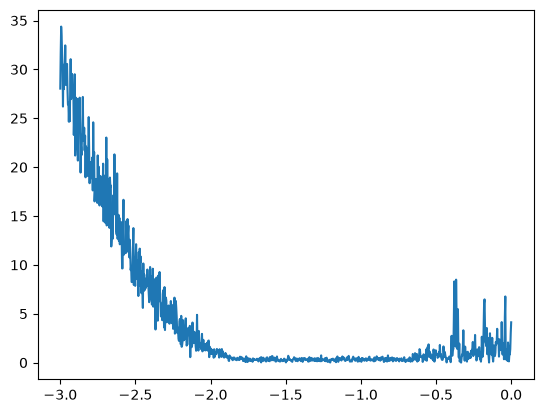

In [78]:
plt.plot(lri, lossi)

A learning rate corresponding to -1 on the log10 scale was roughly a good choice.

In [79]:
# Loss for the whole dataset

emb = C[X] # (32, 3, 10)
h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 200)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Y)
loss

tensor(2.7891, grad_fn=<NllLossBackward0>)

So we choose a good learning rate, start training with it, and decay it toward the end of training.

Train/Dev/Test

In [83]:
def build_dataset(words):
    X, Y = [], []
    for w in words:
        #print(w)
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            #print(''.join(itos[i] for i in context), '--->', itos[ix])
            context = context[1:] + [ix] # crop and append

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y
import random
random.seed(42)
random.shuffle(words)

n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [92]:
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27, 10), generator=g)
W1 = torch.randn((30, 200), generator=g)
b1 = torch.randn(200, generator=g)
W2 = torch.randn((200, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [93]:
sum(p.nelement() for p in parameters) # number of parameters in total

11897

In [94]:
for p in parameters:
  p.requires_grad = True

In [95]:
lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre

In [96]:
lri = []
lossi = []
stepi = []

In [97]:
for i in range(200000):
    
    ix = torch.randint(0, Xtr.shape[0], (32,))
    emb = C[Xtr[ix]]
    h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
    logits = h @ W2 + b2 # (32, 27)
    loss = F.cross_entropy(logits, Ytr[ix])
    for p in parameters:
        p.grad = None
    loss.backward()
    
    # update
    #lr = lrs[i]
    lr = 0.1 if i < 100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    #lri.append(lre[i])
    stepi.append(i)
    lossi.append(loss.log10().item())

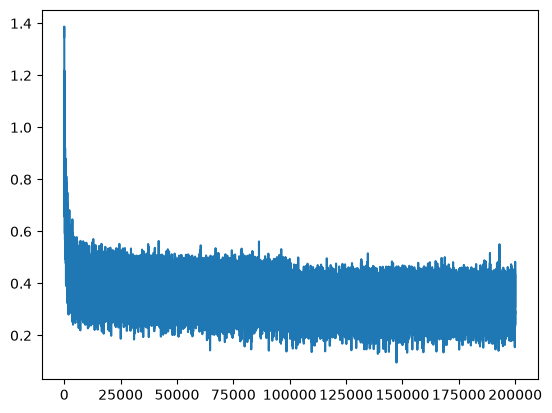

In [98]:
plt.plot(stepi, lossi)

In [ ]:
# Train loss
emb = C[Xtr]  # (num_examples, 3, 10)
h = torch.tanh(emb.view(-1, 30) @ W1 + b1)  # (num_examples, 200)
logits = h @ W2 + b2  # (num_examples, 27)
loss = F.cross_entropy(logits, Ytr)
loss

tensor(2.1256, grad_fn=<NllLossBackward0>)

In [ ]:
# Dev loss
emb = C[Xdev]  # (num_examples, 3, 10)
h = torch.tanh(emb.view(-1, 30) @ W1 + b1)  # (num_examples, 200)
logits = h @ W2 + b2  # (num_examples, 27)
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.1669, grad_fn=<NllLossBackward0>)

In [ ]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    
    out = []
    context = [0] * block_size # initialize with all zeros
    while True:
      emb = C[torch.tensor([context])] # (1,block_size,d)
      h = torch.tanh(emb.view(1, -1) @ W1 + b1)
      logits = h @ W2 + b2
      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      context = context[1:] + [ix]
      out.append(ix)
      if ix == 0:
        break
    
    print(''.join(itos[i] for i in out))

carmah.
amelle.
khyrmley.
taty.
hacessae.
rah.
bradheryst.
kaeli.
nellara.
chaiir.
kaleigh.
ham.
joce.
quint.
sulin.
alian.
quinzelo.
dearynix.
kael.
durathed.
